## Regularization

In [94]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
# DATASET
df = pd.read_csv("/home/deeps/Desktop/Machine_learning_practice/dataset/Boston_house_prices/housing.csv")


In [96]:
df.shape

(505, 1)

In [97]:
#read the dataset and separate the data into columns
df = pd.read_csv("/home/deeps/Desktop/Machine_learning_practice/dataset/Boston_house_prices/housing.csv", sep=r"\s+")

In [98]:
df.head(5)

,0.00632,18.00,2.310,0,0.5380,6.5750,65.20,4.0900,1,296.0,15.30,396.90,4.98,24.00
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


In [99]:
#set column names
df.columns = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT",
    "MEDV"
]

In [100]:
df.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
2,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
3,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
4,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21,28.7


In [101]:
#divide input and output
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [102]:
#Scale the data
mean = np.mean(X, axis=0)
std = np.std(X,axis=0)
X_scaled = (X-mean) / std

In [103]:
#Unscaled data
X_unscaled = X.copy()

In [104]:
"""add intercept on both scaled and unscaled dataset"""
m = X.shape[0]
X_scaled = np.c_[np.ones((m,1)),X_scaled]
X_unscaled = np.c_[np.ones((m,1)),X_unscaled]

In [105]:
## Split the data into training and test dataset using numpy

# change the y DataFrame to numpy
y = y.to_numpy().reshape(-1,1)

#random permutation
shuffle = np.random.permutation(m)

#put random array in X
X_scaled_shuffle = X_scaled[shuffle]
X_unscaled_shuffle = X_unscaled[shuffle]
y_shuffle = y[shuffle]

#Split the data into 80:20 training-testing data
split = int(0.8*m)

#Scaled train test split
Xsc_train = X_scaled_shuffle[:split]
Xsc_test = X_scaled_shuffle[split:]

#Unscaled train test split
Xuc_train = X_unscaled_shuffle[:split]
Xuc_test = X_unscaled_shuffle[split:]

y_train = y_shuffle[:split]
y_test = y_shuffle[split:]



In [120]:
# ============================================
# Ridge Regularization
# ============================================
def ridge(X_train,error,lmbda,weights,N):
    loss = np.mean((error)**2) + (lmbda * np.sum(weights[1:]**2))
    grad_mse = (2/N) * (X_train.T @ error)
    grad_ridge = np.vstack([0,2*lmbda*weights[1:]]) #avoid reguilarizing bias term
    gradient = grad_mse + grad_ridge
    return loss,gradient

In [121]:
# ============================================
# Lasso Regularization
# ============================================
def lasso(X_train,error,alphav,weights,N):
    loss = np.mean((error)**2) + (alphav * np.sum(np.abs(weights[1:])))
    grad_mse = (2/N) * (X_train.T @ error)
    grad_lasso = np.vstack([0,alphav *np.sign(weights[1:])])
    gradient = grad_mse + grad_lasso
    return loss,gradient

In [130]:
def train_model(X_train,y_train,op_type,regrztion,scaled=True):
    weights = np.random.randn(X_scaled.shape[1],1)*0.01
    N = X_train.shape[0]
    epoch = 5000
    loss_fun = []
    learning_rate=0.001
    lmbda=1.0
    alphav = 0.01
    if scaled:
        learning_rate = 0.001
        epoch = 5000
        lmbda = 0.1  
        alphav = 0.001  
    else:
        learning_rate = 1e-9
        epoch = 10000
        lmbda = 10  
        alphav = 1.0  



    if op_type == "batch":
        for i in range(0,epoch):
            y_pred = X_train @ weights

            error = y_train - y_pred

            if regrztion == "ridge":
                loss,gradient = ridge(X_train,error,lmbda,weights,N)

                #update
                weights = weights - learning_rate * gradient
                loss_fun.append(loss)

                if(i%50==0):
                    print(f"At epoch {i}, the loss is {loss}")
            else: #lasso regularization
                loss,gradient = lasso(X_train,error,alphav,weights,N)

                #update
                weights = weights - learning_rate * gradient
                loss_fun.append(loss)

                if(i%50==0):
                    print(f"At epoch {i}, the loss is {loss:.2f}")
    elif op_type == "sgd":
        for i in range(0,epoch):
            shuff = np.random.permutation(N)
            x_j = X_train[shuff]
            y_j = y_train[shuff]

            for j in range(0,N):
                x_s = x_j[j:j+1]
                y_s = y_j[j:j+1]

                y_pred = x_s @ weights

                error = y_pred - y_s
                
                if regrztion == "ridge":
                    _, gradient = ridge(x_s,error,lmbda,weights,1)

                    weights = weights - learning_rate*gradient
                else:
                    _, gradient = lasso(x_s,error,alphav,weights,1)

                    weights = weights - learning_rate*gradient
            
            y_predAll = X_train @ weights
            errorAll = y_predAll - y_train
            loss = 0
            if regrztion == "ridge":
                loss, _ = ridge(X_train,errorAll, lmbda,weights,N)
            else:
                loss, _ = lasso(X_train,errorAll, alphav,weights,N) 

            loss_fun.append(loss)

            if i%50 == 0:
                print(f"At epoch {i}, loss is {loss:.2f}")

    else:   #mini-batch
        batch = 50
        for i in range(0,epoch):
            shuff = np.random.permutation(N)
            x_j = X_train[shuff]
            y_j = y_train[shuff]
            for j in range(0,N,batch):
                x_s = x_j[j:j+batch]
                y_s = y_j[j:j+batch]

                y_pred = x_s@weights

                error = y_pred - y_s
                n = x_s.shape[0]
                if regrztion == "ridge":
                    _, gradient = ridge(x_s,error,lmbda,weights,n)
                    weights = weights - learning_rate*gradient
                else:
                    _, gradient = lasso(x_s,error,alphav,weights,n)
                    weights = weights - learning_rate*gradient

            y_predAll = X_train @ weights
            errorAll = y_predAll - y_train
            loss = 0
            if regrztion == "ridge":
                loss, _ = ridge(X_train,errorAll, lmbda,weights,N)
            else:
                loss, _ = lasso(X_train,errorAll, alphav,weights,N) 

            loss_fun.append(loss)

            if i%50 == 0:
                print(f"At epoch {i}, loss is {loss:.2f}")

    print("Training Complete!!!!")
    print(f"Weights with {regrztion} :: {weights.flatten()}")
    return weights, loss_fun


In [131]:
# Ridge on scaled data
ridge_wScale , ridge_lossScaled = train_model(Xsc_train, y_train, "batch","ridge",scaled=True)

#Ridge on unscaled data
ridge_wUnscale, ridge_lossUnscale = train_model(Xuc_train, y_train, "batch","ridge",scaled=False)

# Lasso on scaled data
lasso_wScale , lasso_lossScaled = train_model(Xsc_train, y_train, "batch","lasso",scaled=True)

#Lasso unscaled data
lasso_wUnscale, lasso_lossUnscale = train_model(Xuc_train, y_train, "batch","lasso",scaled=False)

At epoch 0, the loss is 586.9972901999989
At epoch 50, the loss is 761.6840742202403
At epoch 100, the loss is 1094.028288392705
At epoch 150, the loss is 1901.5867536132323
At epoch 200, the loss is 4244.21214391437
At epoch 250, the loss is 11685.310718948309
At epoch 300, the loss is 36237.065240506505
At epoch 350, the loss is 118429.20425484116
At epoch 400, the loss is 395053.21223499323
At epoch 450, the loss is 1327838.6873190925
At epoch 500, the loss is 4475366.639308447
At epoch 550, the loss is 15098710.864418123
At epoch 600, the loss is 50956929.62432698
At epoch 650, the loss is 171996728.59527123
At epoch 700, the loss is 580571502.7656244
At epoch 750, the loss is 1959736001.1290655
At epoch 800, the loss is 6615177733.143145
At epoch 850, the loss is 22329866293.47176
At epoch 900, the loss is 75375624139.82645
At epoch 950, the loss is 254434365627.9337
At epoch 1000, the loss is 858856541686.8495
At epoch 1050, the loss is 2899115293494.682
At epoch 1100, the loss i

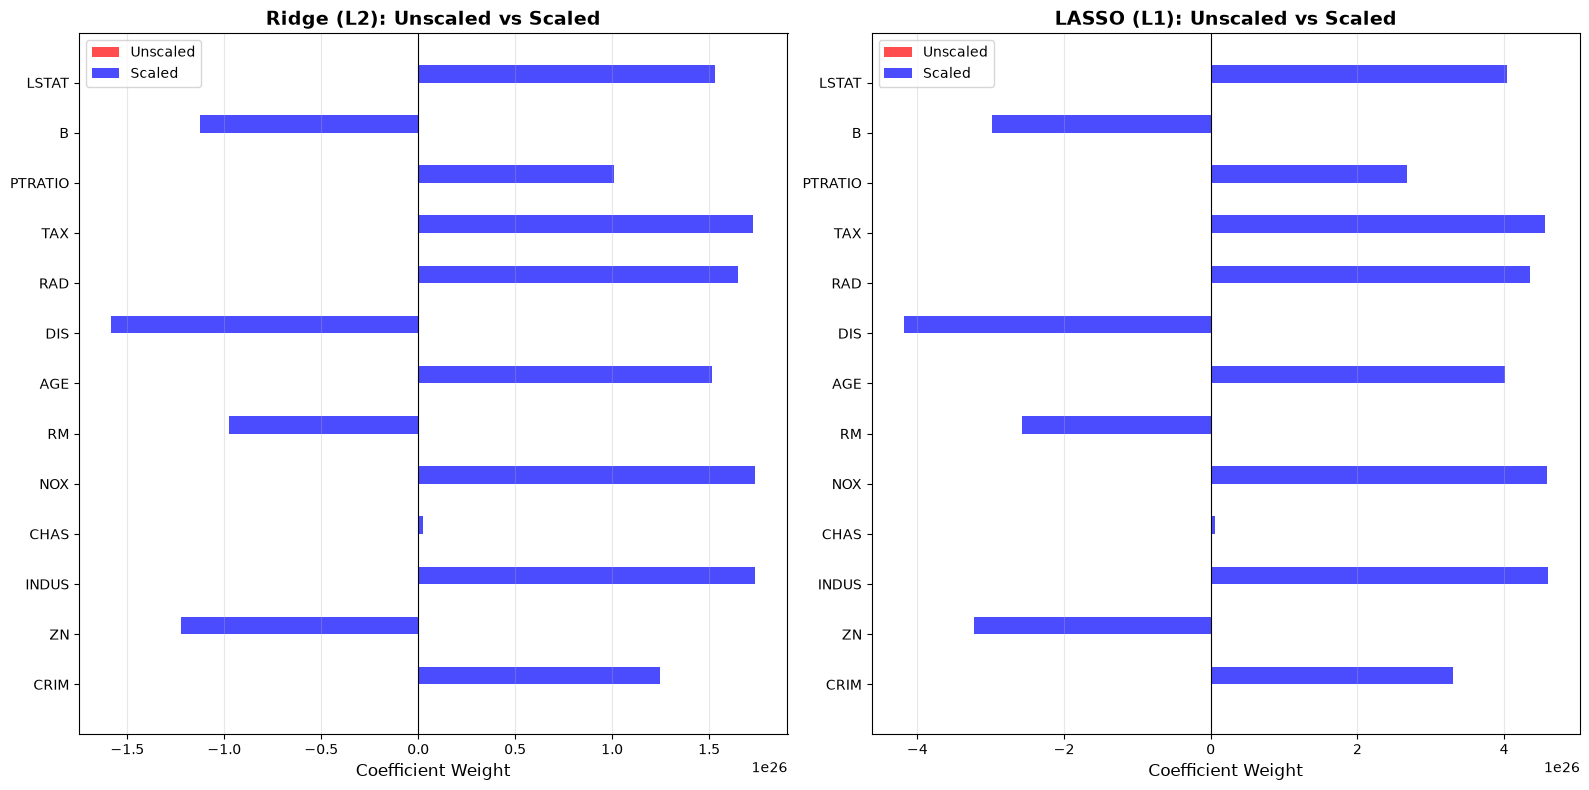

In [132]:
ridge_unscaled = ridge_wUnscale[1:].flatten()
ridge_scaled = ridge_wScale[1:].flatten()
lasso_unscaled = lasso_wUnscale[1:].flatten()
lasso_scaled = lasso_wScale[1:].flatten()

# Feature names
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 
                 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

#PLOT 2 SUBPLOTS SIDE-BY-SIDE 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# X-axis positions for features
x = np.arange(len(feature_names))
width = 0.35  # Bar width

# ============================================
# PLOT 1: RIDGE (Unscaled vs Scaled)
# ============================================
ax1.barh(x - width/2, ridge_unscaled, width, label='Unscaled', color='red', alpha=0.7)
ax1.barh(x + width/2, ridge_scaled, width, label='Scaled', color='blue', alpha=0.7)
ax1.set_yticks(x)
ax1.set_yticklabels(feature_names)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.set_xlabel('Coefficient Weight', fontsize=12)
ax1.set_title('Ridge (L2): Unscaled vs Scaled', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# ============================================
# PLOT 2: LASSO (Unscaled vs Scaled)
# ============================================
ax2.barh(x - width/2, lasso_unscaled, width, label='Unscaled', color='red', alpha=0.7)
ax2.barh(x + width/2, lasso_scaled, width, label='Scaled', color='blue', alpha=0.7)
ax2.set_yticks(x)
ax2.set_yticklabels(feature_names)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Coefficient Weight', fontsize=12)
ax2.set_title('LASSO (L1): Unscaled vs Scaled', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()